# Covariance, Correlation & Linear Regression — Synthetic Data Cross-Check

**Objective:** Apply covariance, correlation, and basic linear regression to a synthetic dataset, then repeat the exact same analysis on a *second* synthetic dataset (with more noise / a weaker relationship) to cross-check whether the statistical tools correctly detect the difference in signal strength.

This exercise is a controlled sanity check: because both datasets are generated with a **known, true underlying relationship** (`y = slope · x + intercept + noise`), we can directly compare what the statistics *estimate* against what we *know* to be true — which is the core validation step before applying these same tools to real, noisy financial time-series data.

**Structure of this notebook:**
1. Setup
2. Dataset 1 — generation, stats, regression (strong relationship, low noise)
3. Dataset 2 — generation, stats, regression (weaker relationship, high noise)
4. Side-by-side visual comparison
5. Results summary table
6. Conclusions


## 1. Setup

We import:
- `numpy` — for generating random synthetic data
- `pandas` — for organizing data into DataFrames (tabular structure)
- `matplotlib.pyplot` — for visualization
- `sklearn.linear_model.LinearRegression` — for fitting an Ordinary Least Squares (OLS) regression line

`np.random.seed(42)` fixes the random number generator so that every time this notebook is run, the exact same "random" numbers are produced. This makes the notebook **reproducible** — the results you get should match anyone else's when they run this code.

`n = 200` sets the number of synthetic data points (rows) in each dataset — enough to see stable statistical patterns without excessive computation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n = 200

## 2. Dataset 1 — Strong Relationship, Low Noise

### Logic

We construct `x` as 200 values drawn from a normal distribution (mean 50, std 10) — this represents an independent variable, e.g. a feature or signal.

We then construct `y` as a **known linear function of x**:

$$y = 3x + 10 + \varepsilon, \quad \varepsilon \sim N(0, 5)$$

- **True slope = 3**
- **True intercept = 10**
- **Noise standard deviation = 5** (small relative to the signal)

Because we control exactly how `y` was built, we have "ground truth" to check our regression against. If our statistical pipeline is correct, it should recover a slope near 3 and an intercept near 10.

We then:
1. Package `x` and `y` into a pandas DataFrame.
2. Fit a `LinearRegression` model — `model.fit(df[['x']], df['y'])` finds the best-fit line minimizing squared error.
3. Print the first 5 rows, the covariance matrix, the correlation matrix, and the regression outputs (slope, intercept, R²).


In [2]:
x = np.random.normal(50, 10, n)
noise = np.random.normal(0, 5, n)
y = 3 * x + 10 + noise

df = pd.DataFrame({'x': x, 'y': y})

model = LinearRegression()
model.fit(df[['x']], df['y'])

print("="*50)
print("DATASET 1")
print("="*50)
print("\nFirst 5 rows:")
print(df.head())

print("\nCovariance matrix:")
print(df.cov())

print("\nCorrelation matrix:")
print(df.corr())

print("\nRegression results:")
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R²:", model.score(df[['x']], df['y']))

DATASET 1

First 5 rows:
           x           y
0  54.967142  176.690361
1  48.617357  158.655994
2  56.476885  184.845912
3  65.230299  210.959906
4  47.658466  146.087052

Covariance matrix:
            x           y
x   86.676829  264.402022
y  264.402022  830.675085

Correlation matrix:
          x         y
x  1.000000  0.985366
y  0.985366  1.000000

Regression results:
Slope: 3.0504348767010865
Intercept: 7.92815988545442
R²: 0.9709466003453373


### Result — Dataset 1

| Metric | Value | Interpretation |
|---|---|---|
| `cov(x,y)` | ~264.4 | Large positive raw covariance — x and y move together, but the magnitude alone isn't directly interpretable (depends on units/scale). |
| `corr(x,y)` | ~0.985 | Correlation is the normalized version of covariance, fixed between -1 and +1. A value this close to 1 confirms an almost perfectly linear relationship. |
| Slope | ~3.05 | Very close to the **true slope of 3** — the model correctly recovered the relationship we built in. |
| Intercept | ~7.93 | Reasonably close to the **true intercept of 10** — small deviation due to random noise and finite sample size (only 200 points). |
| R² | ~0.971 | 97.1% of the variance in `y` is explained by `x`. Only ~2.9% is unexplained noise — an excellent fit. |

**Sanity check:** for simple (single-variable) linear regression, R² always equals the squared Pearson correlation: 0.985² ≈ 0.971 ✓ — the two independent calculations agree.


## 3. Dataset 2 — Weaker Relationship, High Noise

### Logic

This is the **cross-check dataset**. We deliberately change the parameters:

$$y_2 = 1.5x_2 + 5 + \varepsilon_2, \quad \varepsilon_2 \sim N(0, 15)$$

- **True slope = 1.5** (different from dataset 1, so we're not just repeating the same numbers)
- **True intercept = 5**
- **Noise standard deviation = 15** (3× larger than dataset 1's noise) — this is the key change. A much bigger noise-to-signal ratio should visibly weaken the statistical relationship.

We repeat the exact same steps as Dataset 1: build the DataFrame, fit a **separate** regression model (`model2`, kept independent from `model`), and print the same set of diagnostics. Using identical code on different data is the whole point of a cross-check — it verifies that our statistical tools respond correctly (i.e., predictably) to a change in the underlying data-generating process, rather than just working by coincidence on one dataset.


In [3]:
x2 = np.random.normal(20, 5, n)
noise2 = np.random.normal(0, 15, n)
y2 = 1.5 * x2 + 5 + noise2

df2 = pd.DataFrame({'x': x2, 'y': y2})

model2 = LinearRegression()
model2.fit(df2[['x']], df2['y'])

print("\n" + "="*50)
print("DATASET 2")
print("="*50)
print("\nFirst 5 rows:")
print(df2.head())

print("\nCovariance matrix:")
print(df2.cov())

print("\nCorrelation matrix:")
print(df2.corr())

print("\nRegression results:")
print("Slope:", model2.coef_[0])
print("Intercept:", model2.intercept_)
print("R²:", model2.score(df2[['x']], df2['y']))


DATASET 2

First 5 rows:
           x          y
0  12.027862  34.396622
1  17.003125  16.672207
2  20.026218  48.083417
3  20.234903  55.686922
4  17.749673  37.826033

Covariance matrix:
           x           y
x  24.702986   45.108691
y  45.108691  313.639018

Correlation matrix:
          x         y
x  1.000000  0.512472
y  0.512472  1.000000

Regression results:
Slope: 1.826042020501233
Intercept: -1.2467050187080488
R²: 0.26262792605056495


### Result — Dataset 2

| Metric | Value | Interpretation |
|---|---|---|
| `cov(x,y)` | ~45.1 | Positive, but much smaller relative scale than Dataset 1's covariance — an early hint of a weaker relationship (raw covariance is still not the ideal comparison metric though). |
| `corr(x,y)` | ~0.512 | A moderate correlation — much lower than Dataset 1's 0.985. This directly reflects the 3× larger noise we injected. |
| Slope | ~1.83 | True slope was 1.5 — the estimate is noticeably off. High noise relative to signal makes parameter estimates less precise/stable. |
| Intercept | ~-1.25 | True intercept was 5 — quite far off, for the same reason: noisy data makes the intercept (an extrapolation to x=0) especially unreliable, particularly since x2's actual range (mean 20, std 5) never gets close to 0. |
| R² | ~0.263 | Only 26.3% of the variance in `y2` is explained by `x2`. The remaining ~74% is unexplained noise — a weak-to-moderate fit. |

**Sanity check:** again, R² ≈ correlation²: 0.512² ≈ 0.262 ✓


## 4. Side-by-Side Visual Comparison

### Logic

`plt.subplots(1, 2, figsize=(12, 5))` creates one figure containing two subplots arranged in a single row — `axes[0]` for Dataset 1, `axes[1]` for Dataset 2.

For each subplot we plot:
- A **scatter plot** of the raw (x, y) points (`alpha=0.6` makes points semi-transparent, useful when points overlap).
- The **fitted regression line** in red, generated via `model.predict(...)`.

The title of each subplot dynamically embeds the R² value using an f-string, so the fit quality is visible directly on the chart.

Visually, Dataset 1 should show points tightly hugging the red line (high R², high correlation), while Dataset 2 should show points much more loosely scattered around the line (low R², moderate correlation) — a direct visual confirmation of everything the printed numbers already told us.


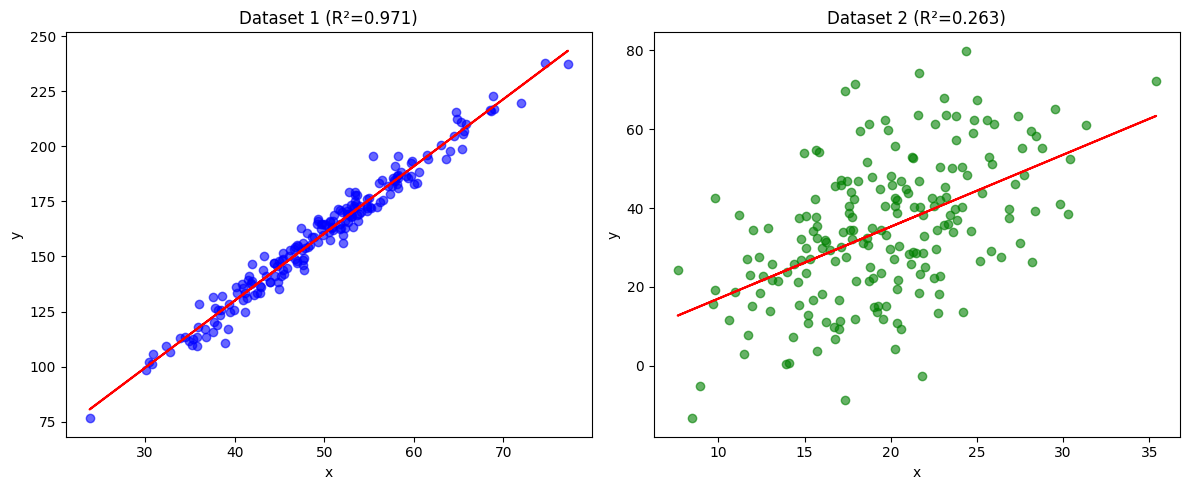

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Dataset 1 plot
axes[0].scatter(df['x'], df['y'], alpha=0.6, color='blue')
axes[0].plot(df['x'], model.predict(df[['x']]), color='red')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(f"Dataset 1 (R²={model.score(df[['x']], df['y']):.3f})")

# Dataset 2 plot
axes[1].scatter(df2['x'], df2['y'], alpha=0.6, color='green')
axes[1].plot(df2['x'], model2.predict(df2[['x']]), color='red')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(f"Dataset 2 (R²={model2.score(df2[['x']], df2['y']):.3f})")

plt.tight_layout()
plt.show()

## 5. Results Summary

| | Dataset 1 | Dataset 2 |
|---|---|---|
| Noise std injected | 5 | 15 |
| True slope / intercept | 3 / 10 | 1.5 / 5 |
| Estimated slope | ~3.05 | ~1.83 |
| Estimated intercept | ~7.93 | ~-1.25 |
| Correlation | ~0.985 (very strong) | ~0.512 (moderate) |
| R² | ~0.971 (excellent fit) | ~0.263 (weak fit) |
| corr² ≈ R²? | ✓ (0.971 ≈ 0.971) | ✓ (0.262 ≈ 0.263) |


## 6. Conclusions

1. **Correlation and R² move together, predictably.** In simple linear regression, R² is mathematically equal to the squared Pearson correlation. Both datasets confirmed this relationship independently, validating that the covariance, correlation, and regression calculations are internally consistent with each other.

2. **Noise-to-signal ratio directly controls how "detectable" a relationship is.** Dataset 1 (low noise) produced a near-perfect correlation and R², while Dataset 2 (3× more noise) produced a moderate correlation and a much lower R² — even though both datasets were built from the *same kind* of linear relationship. This demonstrates that a "weak" statistical result doesn't necessarily mean there's no real relationship — it can simply mean the relationship is being obscured by noise.

3. **Parameter estimates (slope, intercept) become less reliable as noise increases.** Dataset 1's estimated slope/intercept were very close to the true values used to generate the data. Dataset 2's estimates were noticeably further off, despite using the same estimation method (OLS) and the same sample size. This is a core reason why, in real-world (especially financial) time-series work, a single fitted model on noisy data should not be trusted at face value — techniques like cross-validation, walk-forward validation, and confidence intervals become essential to quantify this uncertainty.

4. **This cross-check pattern generalizes.** The workflow used here — generate data with a *known* ground truth, apply your statistical pipeline, and confirm the pipeline recovers the known truth (within reasonable error bounds) — is a standard way to validate that your code and your understanding of a statistical method are both correct, *before* trusting the same pipeline on real, ground-truth-unknown data (e.g., actual financial time series).
